In [32]:
%matplotlib inline

In [33]:
from pandas import *
import numpy
import numpy as np
import matplotlib.pyplot as plt
from random import shuffle

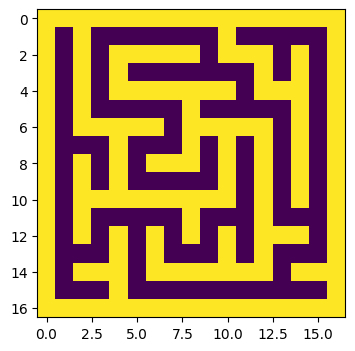

In [34]:
def make_maze(w , h):
    vis = [[0] * w + [1] for _ in range(h)] + [[1] * (w + 1)]
    ver = [["10"] * w + ['1'] for _ in range(h)] + [[]]
    hor = [["11"] * w + ['1'] for _ in range(h + 1)]
 
    def walk(x, y):
        vis[y][x] = 1
 
        d = [(x - 1, y), (x, y + 1), (x + 1, y), (x, y - 1)]
        shuffle(d)
        for (xx, yy) in d:
            if vis[yy][xx]: continue
            if xx == x: hor[max(y, yy)][x] = "10"
            if yy == y: ver[y][max(x, xx)] = "00"
            walk(xx, yy)
 
    walk(numpy.random.randint(w), numpy.random.randint(h))
 
    s = ""
    for (a, b) in zip(hor, ver):
        s += ''.join(a + ['\n'] + b + ['\n'])
        
    M=[]
    for line in s.split("\n"):
        if line!="":
            R=[]
            for e in line:
                R.append(int(e))
            M.append(R)
    return M

maze = np.array(make_maze(8, 8))

plt.figure(figsize=(4, 4))
plt.imshow(maze)   # or "gray"
plt.show()

In [ ]:
import heapq

def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def astar(maze, start, goal):
    rows, cols = maze.shape

    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g_score = {start: 0}
    f_score = {start: heuristic(start, goal)}

    closed_set = set()

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        closed_set.add(current)

        x, y = current
        for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
            nx, ny = x + dx, y + dy

            if not (0 <= nx < rows and 0 <= ny < cols):
                continue
            if maze[nx, ny] == 1:
                continue

            neighbor = (nx, ny)
            tentative_g = g_score[current] + 1

            if neighbor in closed_set and tentative_g >= g_score.get(neighbor, float("inf")):
                continue

            if tentative_g < g_score.get(neighbor, float("inf")):
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f_score[neighbor] = tentative_g + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f_score[neighbor], neighbor))

    return None


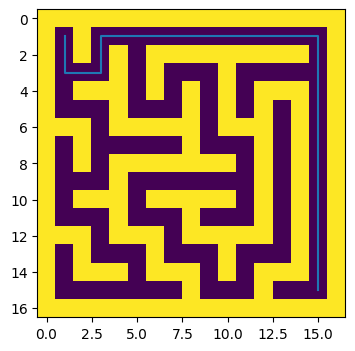

In [ ]:
maze = np.array(make_maze(8, 8))

start = (1, 1)
goal  = (15, 15) # Samma storlek som maze-koden vi fått.

path = astar(maze, start, goal)

plt.figure(figsize=(4,4))
plt.imshow(maze)

if path:
    ys = [p[1] for p in path]
    xs = [p[0] for p in path]
    plt.plot(ys, xs)

plt.show()